# Modelo Clasificatorio para la Deteccion de Diabetes

En este proyecto realizaremos un modelo clasificatorio de machine learning entrenado para predecir la diabetes en un paciente según una serie de datos médicos como los nuveles de glucosa en sangre, el IMC, la presión sanguínea, etc. Serán empleados varios algoritmos de clasificación para analizar cuál proporciona los mejores resultados.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.DataFrame(pd.read_csv("diabetes.csv"))

## Análisis Exploratorio de los Datos

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB



##### El dataset se compone de 768 filas en las que se observan 9 variables, 8 de ellas de carácter médico y la última el diagnóstico de la diabetes (1 para diabético y 0 para no diabético). Comenzaremos analizando la distribución de los datos en cada una de las variables.

In [19]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [20]:
df.isnull().any()

Pregnancies                 False
Glucose                     False
BloodPressure               False
SkinThickness               False
Insulin                     False
BMI                         False
DiabetesPedigreeFunction    False
Age                         False
Outcome                     False
dtype: bool

El dataset no contiene ningún tipo de dato perdido.

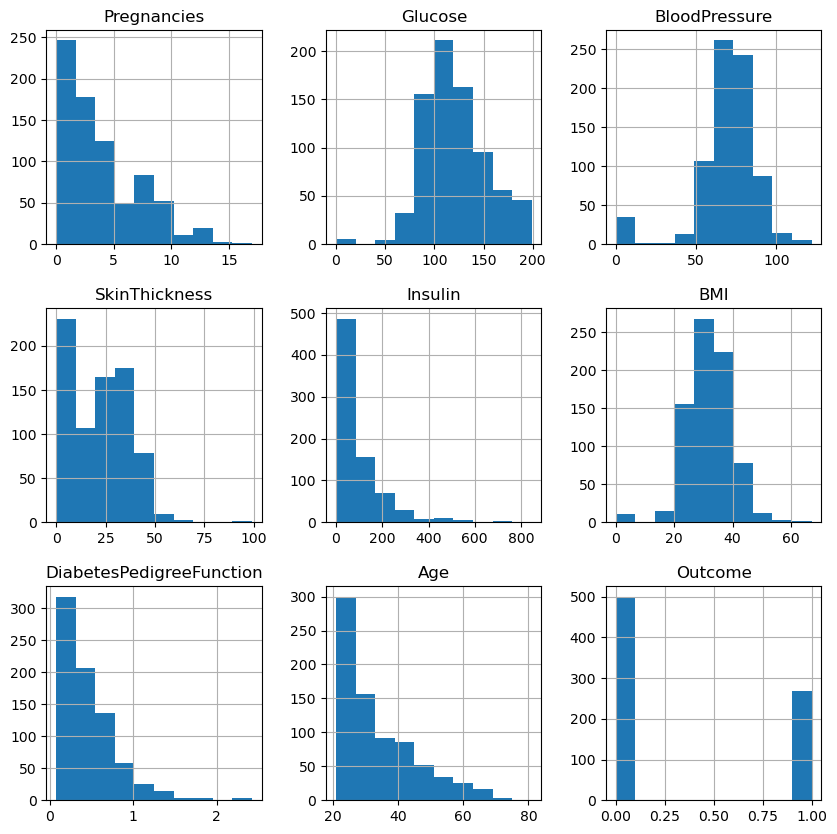

In [21]:
df.hist(figsize = (10,10))
plt.show()

A pesar de no contar con ningun dato perdido, hay bastantes variables(insulina, BMI, presión sanguinea...) que toman el valor 0 en muchas ocasiones. Esto nos lleva a deducir que en el dataset los valores perdidos han sido tomados como 0. Para que no distorsione el modelado los convertiremos a NAs así el algoritmo los ignorará al entrenar el modelo. 

In [22]:
columnas_cero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[columnas_cero] = df[columnas_cero].replace(0, np.nan)
for col in columnas_cero:
  df[col] = df[col].fillna(df[col].median())

In [23]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


<Axes: >

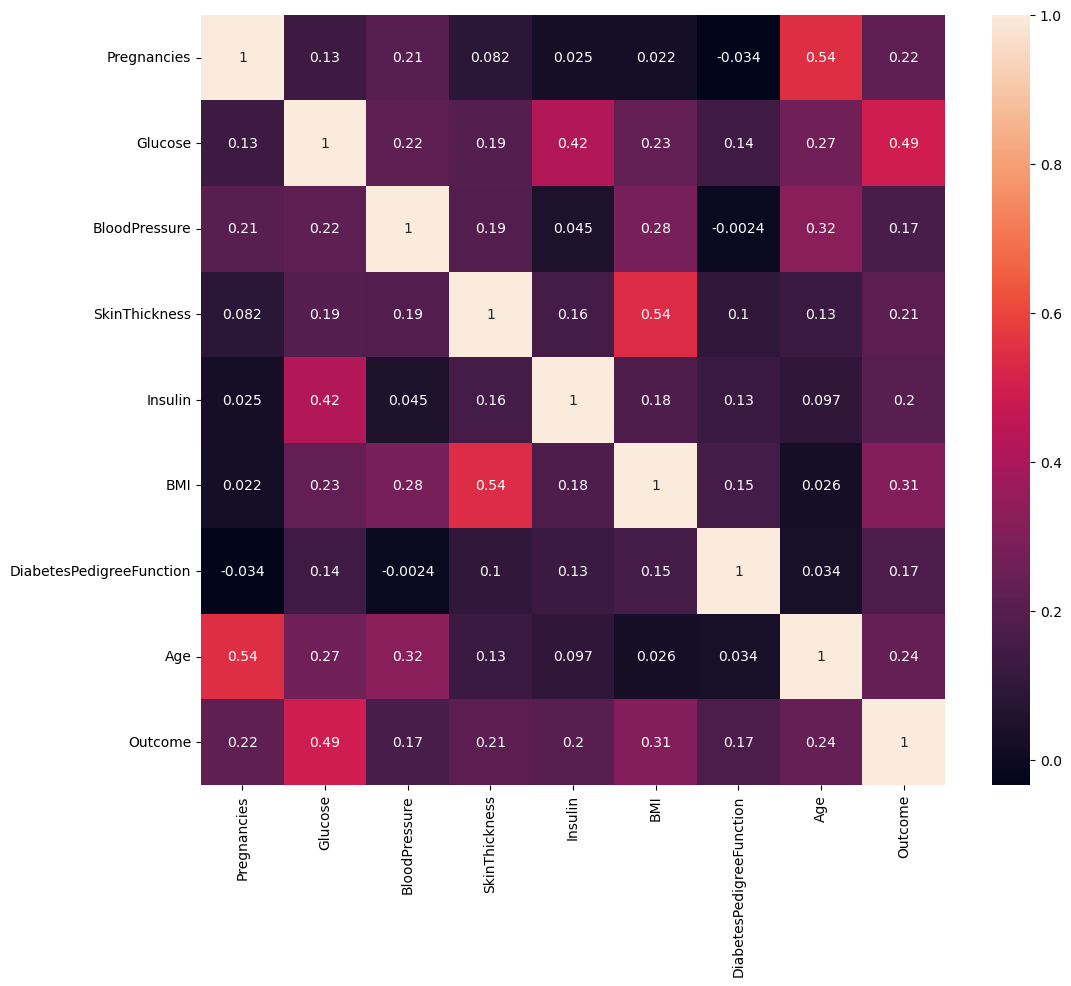

In [24]:
plt.figure(figsize = (12,10))
sns.heatmap(df.corr(),annot = True)

La matriz de correlaciones nos muestra una importante relación lineal entre nos niveles de glucosa y el diagnóstico de la diabetes, por otro lado, variables como la presión sanguínea o el grosor de la piel son prácticamente irrelevantes al resultado. Además, cabe destacar la baja correlación entre el diagnóstico de la diabetes y los niveles de insulina, a pesar de que esta es una hormona ampliamente realcionada con la enfermedad.

C:\Users\apezo\AppData\Local\Temp\ipykernel_9376\712467204.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df['Outcome'],palette='Set1')


<Axes: xlabel='count', ylabel='Outcome'>

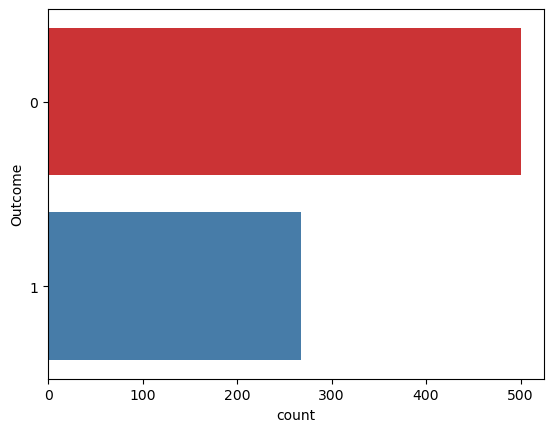

In [25]:
sns.countplot(y=df['Outcome'],palette='Set1')

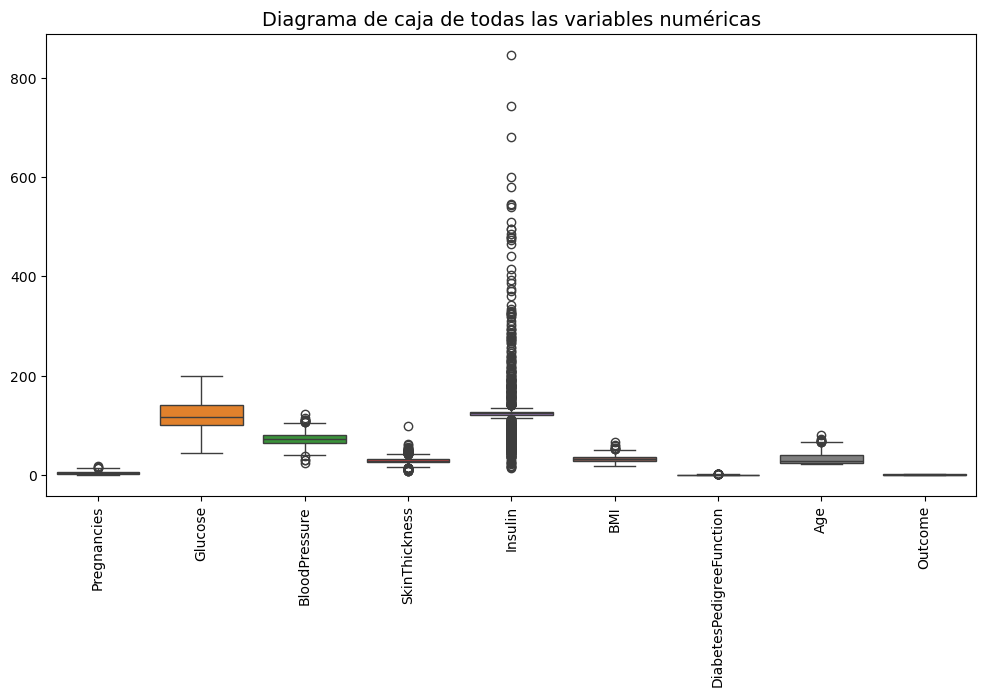

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Selecciona solo las columnas numéricas del DataFrame
sns.boxplot(data=df.select_dtypes(include=['number']))

plt.title(
    'Diagrama de caja de todas las variables numéricas',
    fontsize=14,
)
plt.xticks(rotation=90)  # Rota los nombres si son muy largos
plt.show()

## Fase de Modelizacón

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler


# Construimos los array train/test de X e y
X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis=1),
                                                    df['Outcome'], test_size=0.20,
                                                    random_state=101)

# Creamos el modelo y lo entrenamos con parte de la muestra de datos
param_grid = {'penalty': ['l2'], #Tipo de regularización
              'C': [0.01, 0.1, 1, 10, 100], #Parámetro de regularización 
              'solver': ['lbfgs', 'newton-cg']} #Algoritmo para minimizar el coste

clasificadores = GridSearchCV(LogisticRegression(max_iter=400), param_grid, cv=3, n_jobs=-1)
clasificadores.fit(X_train, y_train)

logmodel = LogisticRegression(max_iter=400, penalty=clasificadores.best_params_["penalty"], C=clasificadores.best_params_["C"], solver=clasificadores.best_params_["solver"])
logmodel.fit(X_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,400
,multi_class,'deprecated'


In [6]:
# Realizamos las predicciones sobre la parte restante de los datos y evaluaremos los resultados
from sklearn.metrics import classification_report, confusion_matrix

# Predicciones regresión logística
predictions = logmodel.predict(X_test)
print(classification_report(y_test,predictions))
print(confusion_matrix(y_test,predictions))



              precision    recall  f1-score   support

           0       0.83      0.87      0.85       103
           1       0.72      0.65      0.68        51

    accuracy                           0.80       154
   macro avg       0.78      0.76      0.77       154
weighted avg       0.79      0.80      0.80       154

[[90 13]
 [18 33]]
